# 02 · Demand and opportunity score

Phase 1 showed that stationery and copy shops are scarce near Campus Monterrey. This notebook asks whether **there are customers where the shops are missing**.

**Inputs** (built by `src/build_demand.py`):
- `ageb_demand.geojson`: urban block groups (AGEB) near the campus, with 2020 Census population.
- `grid_scores.csv`: 250 m grid cells within 1.5 km of the campus, with demand and competition inside a 500 m walk (about 6 minutes).

**Opportunity score** = residents aged 18–24 within 500 m ÷ (stationery + copy shops within 500 m + 1).

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent
sys.path.append(str(ROOT / "src"))
from config import CAMPUSES, TARGET_CAMPUS

agebs = gpd.read_file(ROOT / "data/processed/ageb_demand.geojson")
grid = pd.read_csv(ROOT / "data/processed/grid_scores.csv")
biz = pd.read_parquet(ROOT / "data/processed/metro_businesses.parquet")
lat0, lon0 = CAMPUSES[TARGET_CAMPUS]

SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3de"
BLUE, ORANGE = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})

def direction(lat, lon):
    dy, dx = lat - lat0, (lon - lon0) * np.cos(np.radians(lat0))
    ang = (np.degrees(np.arctan2(dx, dy)) + 360) % 360
    return ["N", "NE", "E", "SE", "S", "SW", "W", "NW"][int(((ang + 22.5) % 360) // 45)]

grid["where"] = [f"{d:.0f} m {direction(a, b)}" for d, a, b in zip(grid.dist_campus_m, grid.lat, grid.lon)]
print(f"{len(agebs)} AGEBs and {len(grid)} grid cells around the campus")

44 AGEBs and 113 grid cells around the campus


## 1. Who lives around the campus?

In [2]:
within = agebs.copy()
summary = pd.Series({
    "Residents (AGEBs touching the study area)": int(within.POBTOT.sum()),
    "Residents aged 18–24": int(within.P_18A24.sum()),
    "Share aged 18–24": f"{within.P_18A24.sum() / within.POBTOT.sum():.1%}",
    "Inhabited dwellings": int(within.TVIVPARHAB.sum()),
})
summary.to_frame("value")

,value
Residents (AGEBs touching the study area),118109
Residents aged 18–24,14732
Share aged 18–24,12.5%
Inhabited dwellings,37760


In [3]:
census = pd.read_csv(ROOT / "data/raw/censo2020_ageb_mza_nl.csv", dtype=str, encoding="utf-8-sig")
state = census[census.MUN == "000"].iloc[0]
nl_share = int(state.P_18A24) / int(state.POBTOT)
grid["share_18_24"] = grid.P_18A24 / grid.POBTOT
print(f"Nuevo León overall: {nl_share:.1%} of residents are 18–24")
print(f"Whole study area:   {within.P_18A24.sum() / within.POBTOT.sum():.1%}")
print(f"Top-5 cells (500 m walk): {grid.nlargest(5, 'youth_per_competitor').share_18_24.min():.0%}–"
      f"{grid.nlargest(5, 'youth_per_competitor').share_18_24.max():.0%}")
agebs.sort_values("share_18_24", ascending=False)[["CVEGEO", "POBTOT", "P_18A24", "share_18_24"]].head(5)

Nuevo León overall: 12.1% of residents are 18–24
Whole study area:   12.5%
Top-5 cells (500 m walk): 18%–28%


,CVEGEO,POBTOT,P_18A24,share_18_24
19,1903900012010,377,258.0,0.684
23,1903900012097,4087,1337.0,0.327
21,1903900014661,2902,743.0,0.256
14,190390001210A,2790,490.0,0.176
2,190390001445A,5563,901.0,0.162


Across the whole 1.5 km area, the 18–24 share is close to the state average. Young adults are **concentrated in a few AGEBs right next to the campus**, and around the three best-scoring cells they are roughly **twice the state share**. That concentration is the student market.

## 2. Where is the opportunity?
Top 10 grid cells by opportunity score. The label is the distance and direction from the campus centroid.

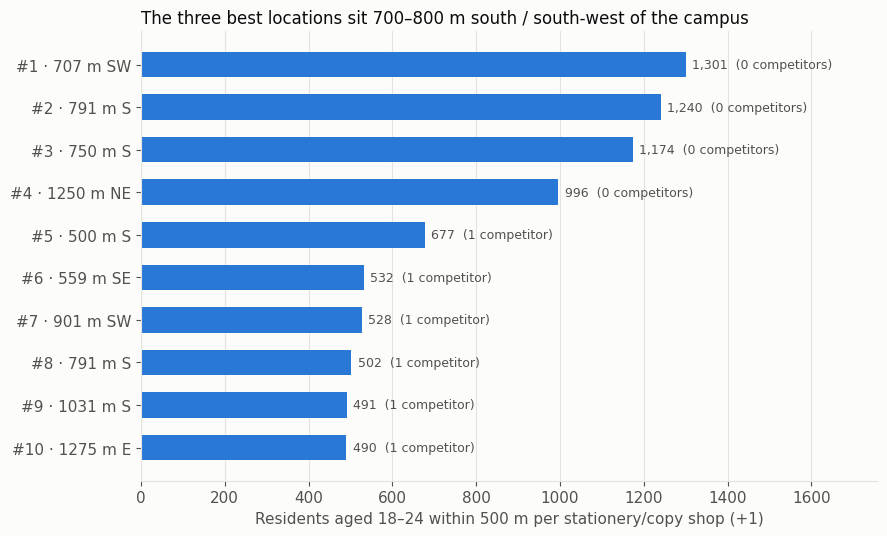

,where,POBTOT,P_18A24,competitors_500m,nearest_competitor_m,businesses_250m,youth_per_competitor
31,707 m SW,5310.0,1301.0,0,514.0,50,1301.0
41,791 m S,5319.0,1240.0,0,652.0,21,1240.0
53,750 m S,5155.0,1174.0,0,576.0,83,1174.0
103,1250 m NE,5495.0,996.0,0,528.0,23,996.0
54,500 m S,4865.0,1354.0,1,347.0,105,677.0
66,559 m SE,4651.0,1064.0,1,308.0,83,532.0
30,901 m SW,5192.0,1057.0,1,461.0,34,528.0
65,791 m S,4931.0,1004.0,1,494.0,86,502.0
40,1031 m S,5524.0,982.0,1,460.0,10,491.0
109,1275 m E,5670.0,980.0,1,125.0,155,490.0


In [4]:
top = grid.sort_values("youth_per_competitor", ascending=False).head(10)
top["label"] = [f"#{i} · {w}" for i, w in enumerate(top["where"], start=1)]
top = top.iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(np.arange(len(top)), top["youth_per_competitor"], color=BLUE, height=0.6)
ax.set_yticks(np.arange(len(top)))
ax.set_yticklabels(top["label"])
for y, (v, n) in enumerate(zip(top["youth_per_competitor"], top["competitors_500m"])):
    ax.text(v + 15, y, f"{v:,.0f}  ({n} competitor{'s' if n != 1 else ''})", va="center", color=INK_2, fontsize=9)
ax.set_xlim(0, top["youth_per_competitor"].max() * 1.35)
ax.grid(axis="x", color=GRID, lw=0.8)
ax.set_axisbelow(True)
ax.set_title("The three best locations sit 700–800 m south / south-west of the campus", loc="left", fontsize=12)
ax.set_xlabel("Residents aged 18–24 within 500 m per stationery/copy shop (+1)")
fig.tight_layout()
fig.savefig(ROOT / "docs/opportunity_top10.png", dpi=150, bbox_inches="tight")
plt.show()
cols = ["where", "POBTOT", "P_18A24", "competitors_500m", "nearest_competitor_m", "businesses_250m", "youth_per_competitor"]
grid.sort_values("youth_per_competitor", ascending=False)[cols].head(10).round(0)

## 3. Robustness check
A recommendation should not depend on a single modelling choice. Do the top locations survive if we score on **total population** instead of 18–24 year-olds?

In [5]:
alt = grid.assign(alt_score=grid.POBTOT / (grid.competitors_500m + 1))
top_youth = set(grid.nlargest(5, "youth_per_competitor").cell_id)
top_total = set(alt.nlargest(5, "alt_score").cell_id)
print(f"Top-5 cells shared by both scores: {len(top_youth & top_total)} of 5")
print("Cells only in the 18-24 top 5:", sorted(top_youth - top_total))
print("Cells only in the total-population top 5:", sorted(top_total - top_youth))

Top-5 cells shared by both scores: 4 of 5
Cells only in the 18-24 top 5: [54]
Cells only in the total-population top 5: [96]


## 4. Map
AGEBs are shaded by the share of residents aged 18–24 (darker = more young adults). Black squares are the top 5 cells, orange dots are existing stationery and copy shops. Saved to `docs/map_opportunity.html`.

In [6]:
import folium

m = folium.Map(location=[lat0, lon0], zoom_start=15, tiles="OpenStreetMap")
folium.Choropleth(geo_data=agebs.to_json(), data=agebs, columns=["CVEGEO", "share_18_24"],
                  key_on="feature.properties.CVEGEO", name="Share aged 18–24 (AGEB)", fill_color="Blues", fill_opacity=0.55,
                  line_opacity=0.3, nan_fill_color="#e4e3de",
                  legend_name="Share of residents aged 18–24 (Census 2020)").add_to(m)
folium.GeoJson(agebs[["CVEGEO", "POBTOT", "P_18A24", "share_18_24", "geometry"]].to_json(),
               style_function=lambda f: {"fillOpacity": 0, "weight": 0}, control=False,
               tooltip=folium.GeoJsonTooltip(["POBTOT", "P_18A24", "share_18_24"],
                                             aliases=["Residents", "Aged 18–24", "Share 18–24"])).add_to(m)
folium.Marker([lat0, lon0], tooltip="Tec de Monterrey · Campus Monterrey",
              icon=folium.Icon(color="darkblue", icon="graduation-cap", prefix="fa")).add_to(m)
comp = biz[biz.categoria.isin(["papeleria", "fotocopiado_impresion"]) & (biz.dist_tec_campus_monterrey_m <= 2200)]
fg = folium.FeatureGroup(name="Stationery & copy shops")
for _, b in comp.iterrows():
    folium.CircleMarker([b.latitud, b.longitud], radius=6, color="#ffffff", weight=2, fill=True,
                        fill_color=ORANGE, fill_opacity=0.95,
                        tooltip=f"<b>{b.nom_estab}</b><br>{b.nombre_act}").add_to(fg)
fg.add_to(m)
step_lat = 250 / 111_320
step_lon = 250 / (111_320 * np.cos(np.radians(lat0)))
best = folium.FeatureGroup(name="Top 5 cells")
for rank, (_, g) in enumerate(grid.nlargest(5, "youth_per_competitor").iterrows(), start=1):
    folium.Rectangle([[g.lat - step_lat / 2, g.lon - step_lon / 2], [g.lat + step_lat / 2, g.lon + step_lon / 2]],
                     color=INK, weight=2.5, fill=True, fill_opacity=0.1,
                     tooltip=f"#{rank} · {g['where']} · {g.P_18A24:,.0f} residents aged 18–24 within 500 m · "
                             f"{g.competitors_500m} competitor(s)").add_to(best)
best.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
m.save(ROOT / "docs/map_opportunity.html")
m

Map saved to docs/map_opportunity.html (open it in a browser; GitHub does not render interactive maps).


## 5. Findings and draft recommendation

1. **Demand is concentrated, not everywhere.** Across the whole area the 18–24 share matches the state (about 12%), but around the three best-scoring cells it is 23–25%, about twice as high.
2. **The gap is south / south-west of the campus.** The three best cells sit 700–800 m away, each with 1,170–1,300 residents aged 18–24 within a 6-minute walk and **no stationery or copy shop** in that radius. The ranking holds when scoring on total population: 4 of the top 5 cells are the same.
3. **Draft recommendation:** a combined stationery + print/copy shop south of the campus, inside the top-ranked cells. Validate on foot before committing.

**Limitations**
- The Census counts *residents*. Students who commute to campus and pass through are not captured, and on-campus residences may be under-represented.
- INEGI masks small AGEB counts with `*`. Those are treated as unknown, so demand is slightly under-estimated.
- Areal interpolation assumes people are evenly spread inside each AGEB.
- DENUE misses informal businesses and services inside the campus.

**Next steps:** field validation checklist, a Tableau Public dashboard, and a one-page business memo.